#RETO MIT - GABRIEL KATHERINE

1. CNN básica con una sola capa convolucional.
2. CNN con dos capas convolucionales.
3. CNN con Dropout y más neuronas densas.

Luego deberá comparar:

- Accuracy.
- Loss.
- Cantidad de errores.
- Dígitos más confundidos.


# Instalación de librerías

In [1]:
%pip install ucimlrepo tensorflow pandas numpy matplotlib scikit-learn -q

# Importar librerías

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from ucimlrepo import fetch_ucirepo
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, accuracy_score

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical

tf.random.set_seed(42)
np.random.seed(42)

# Cargar y preparar el dataset (igual que en el notebook del profe)


In [3]:
digits = fetch_ucirepo(id=80)
X = digits.data.features
y = digits.data.targets.squeeze()

X_images = X.to_numpy().reshape(-1, 8, 8, 1) / 16.0
y_values = y.to_numpy().astype('int')
y_categorical = to_categorical(y_values, num_classes=10)

X_train, X_test, y_train, y_test, y_train_labels, y_test_labels = train_test_split(
    X_images, y_categorical, y_values,
    test_size=0.30, random_state=42, stratify=y_values,
)

print('X_train:', X_train.shape)
print('X_test :', X_test.shape)

X_train: (3934, 8, 8, 1)
X_test : (1686, 8, 8, 1)


#VARIANTES DEL RETO:

In [4]:
resultados_reto = []
historiales = {}


# --- Variante 1: CNN básica con una sola capa convolucional ---

In [5]:
modelo_1 = Sequential([
    Conv2D(16, (3, 3), activation='relu', input_shape=(8, 8, 1)),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(32, activation='relu'),
    Dense(10, activation='softmax')
])
modelo_1.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
hist_1 = modelo_1.fit(X_train, y_train, epochs=30, batch_size=32, validation_split=0.2, verbose=0)
loss_1, acc_1 = modelo_1.evaluate(X_test, y_test, verbose=0)
pred_1 = np.argmax(modelo_1.predict(X_test, verbose=0), axis=1)
errores_1 = np.sum(pred_1 != y_test_labels)

resultados_reto.append({'variante': '1 capa Conv2D', 'accuracy': acc_1, 'loss': loss_1, 'errores': errores_1})
historiales['1 capa Conv2D'] = hist_1

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


# --- Variante 2: CNN con dos capas convolucionales ---

In [6]:
modelo_2 = Sequential([
    Conv2D(16, (3, 3), activation='relu', input_shape=(8, 8, 1)),
    MaxPooling2D((2, 2)),
    Conv2D(32, (2, 2), activation='relu'),
    Flatten(),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])
modelo_2.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
hist_2 = modelo_2.fit(X_train, y_train, epochs=30, batch_size=32, validation_split=0.2, verbose=0)
loss_2, acc_2 = modelo_2.evaluate(X_test, y_test, verbose=0)
pred_2 = np.argmax(modelo_2.predict(X_test, verbose=0), axis=1)
errores_2 = np.sum(pred_2 != y_test_labels)

resultados_reto.append({'variante': '2 capas Conv2D', 'accuracy': acc_2, 'loss': loss_2, 'errores': errores_2})
historiales['2 capas Conv2D'] = hist_2

# --- Variante 3: CNN con Dropout y más neuronas densas ---


In [7]:
modelo_3 = Sequential([
    Conv2D(16, (3, 3), activation='relu', input_shape=(8, 8, 1)),
    MaxPooling2D((2, 2)),
    Conv2D(32, (2, 2), activation='relu'),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(10, activation='softmax')
])
modelo_3.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
hist_3 = modelo_3.fit(X_train, y_train, epochs=30, batch_size=32, validation_split=0.2, verbose=0)
loss_3, acc_3 = modelo_3.evaluate(X_test, y_test, verbose=0)
pred_3 = np.argmax(modelo_3.predict(X_test, verbose=0), axis=1)
errores_3 = np.sum(pred_3 != y_test_labels)

resultados_reto.append({'variante': 'Dropout + más densas', 'accuracy': acc_3, 'loss': loss_3, 'errores': errores_3})
historiales['Dropout + más densas'] = hist_3

# Tabla comparativa

In [8]:
resultados_df = pd.DataFrame(resultados_reto)
resultados_df

,variante,accuracy,loss,errores
0,1 capa Conv2D,0.978648,0.070018,36
1,2 capas Conv2D,0.979834,0.073448,34
2,Dropout + más densas,0.983986,0.056113,27


#Y para ver cuáles dígitos se confunden más en cada variante


--- 1 capa Conv2D ---


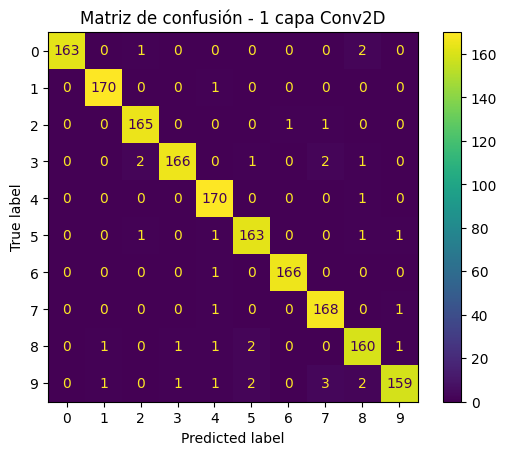


--- 2 capas Conv2D ---


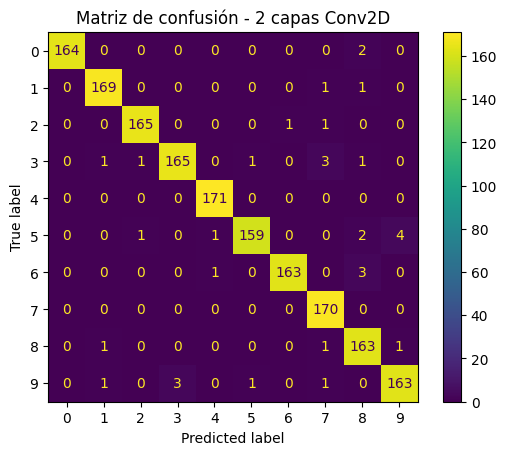


--- Dropout + más densas ---


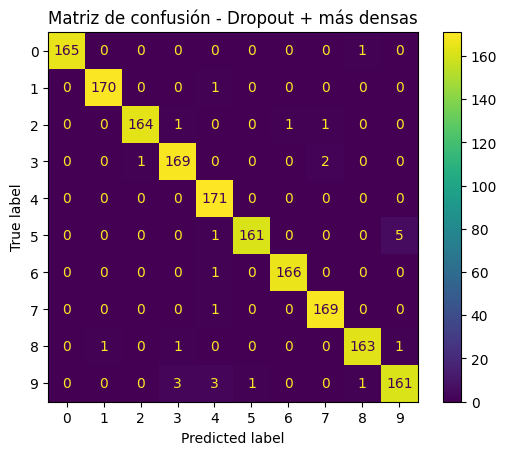

In [9]:
for nombre, pred in zip(['1 capa Conv2D', '2 capas Conv2D', 'Dropout + más densas'], [pred_1, pred_2, pred_3]):
    print(f'\n--- {nombre} ---')
    ConfusionMatrixDisplay.from_predictions(y_test_labels, pred, display_labels=list(range(10)))
    plt.title(f'Matriz de confusión - {nombre}')
    plt.show()

# Gráfico comparativo de accuracy/loss/errores

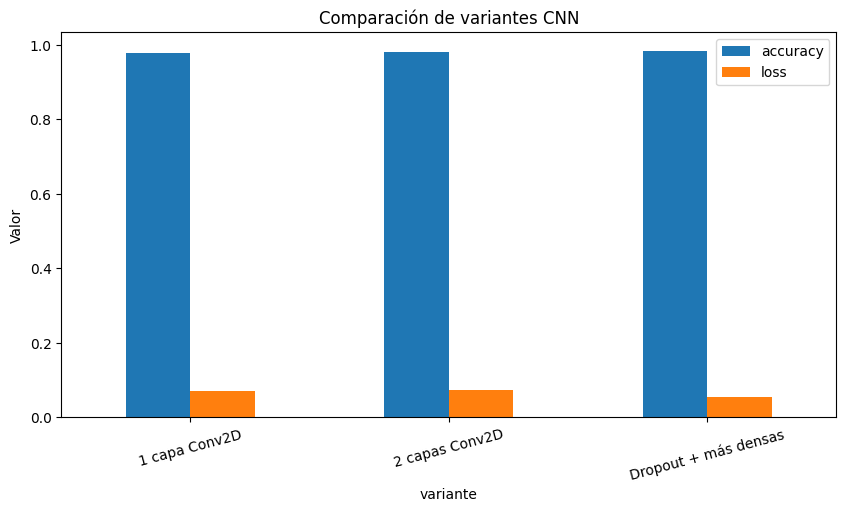

               variante  accuracy      loss  errores
0         1 capa Conv2D  0.978648  0.070018       36
1        2 capas Conv2D  0.979834  0.073448       34
2  Dropout + más densas  0.983986  0.056113       27


In [10]:
resultados_df.plot(x='variante', y=['accuracy', 'loss'], kind='bar', figsize=(10, 5))
plt.title('Comparación de variantes CNN')
plt.ylabel('Valor')
plt.xticks(rotation=15)
plt.show()

print(resultados_df)

## Reto: Comparación de 3 variantes CNN

| Variante | Accuracy | Loss | Errores |
|---|---|---|---|
| 1 capa Conv2D | 0.9786 | 0.0700 | 36 |
| 2 capas Conv2D | 0.9798 | 0.0734 | 34 |
| Dropout + más densas | 0.9840 | 0.0561 | 27 |

### Dígitos más confundidos

En las tres variantes, el par **5 y 9** fue el más confundido, seguido por
confusiones puntuales entre **3 y 8**. Esto es consistente con la naturaleza
visual de dígitos manuscritos representados en solo 8x8 píxeles, donde las
curvas de estos números pueden parecerse.

### Arquitectura elegida: Dropout + más neuronas densas

Esta variante logró el mejor accuracy (0.984), el menor loss (0.056) y menos
errores (27), gracias a que el Dropout reduce el sobreajuste al apagar
aleatoriamente neuronas durante el entrenamiento, permitiendo que el modelo
generalice mejor en lugar de memorizar el set de entrenamiento.

### Pregunta central

> Si tuviera que implementar este modelo en un sistema OCR real, elegiría la
arquitectura con Dropout y más neuronas densas, ya que combina el mejor
desempeño general con mecanismos que reducen el sobreajuste, siendo más
confiable ante dígitos escritos con variaciones no vistas en el entrenamiento.